Balance de Clases:
target
1    0.574956
0    0.425044
Name: proportion, dtype: float64
Balance de Clases:
target
1    0.532095
0    0.467905
Name: proportion, dtype: float64

 Features eliminadas por correlación alta: ['High', 'Low', 'Close', 'Adj Close', 'SMA_20', 'SMA_50', 'Signal_Line', 'Adj Close_norm', 'Volume_norm', 'year', 'SMA_10', 'Bollinger_Middle', 'Bollinger_High', 'Bollinger_Low', 'Volume_Change', 'rolling_mean_3d', 'rolling_mean_5d', 'rolling_std_3d', 'rolling_return_3d', 'Close_lag_1', 'Close_lag_3', 'Close_lag_5', 'Open_lag_1', 'Open_lag_3', 'Open_lag_5', 'RSI_14_lag_1', 'MACD_diff_lag_1']

 Features seleccionadas por importancia: 35 de 49 iniciales.


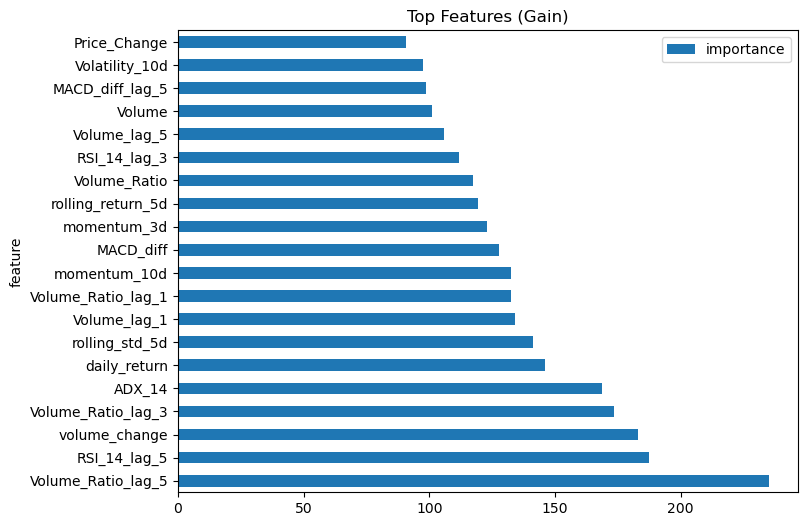


 Features eliminadas por correlación alta: ['High', 'Low', 'Close', 'Adj Close', 'SMA_20', 'SMA_50', 'Signal_Line', 'Adj Close_norm', 'Volume_norm', 'year', 'SMA_10', 'Bollinger_Middle', 'Bollinger_High', 'Bollinger_Low', 'rolling_mean_3d', 'rolling_mean_5d', 'rolling_std_3d', 'rolling_return_3d', 'Close_lag_1', 'Close_lag_3', 'Close_lag_5', 'Open_lag_1', 'Open_lag_3', 'Open_lag_5', 'RSI_14_lag_1', 'MACD_diff_lag_1']

 Features seleccionadas por importancia: 37 de 50 iniciales.


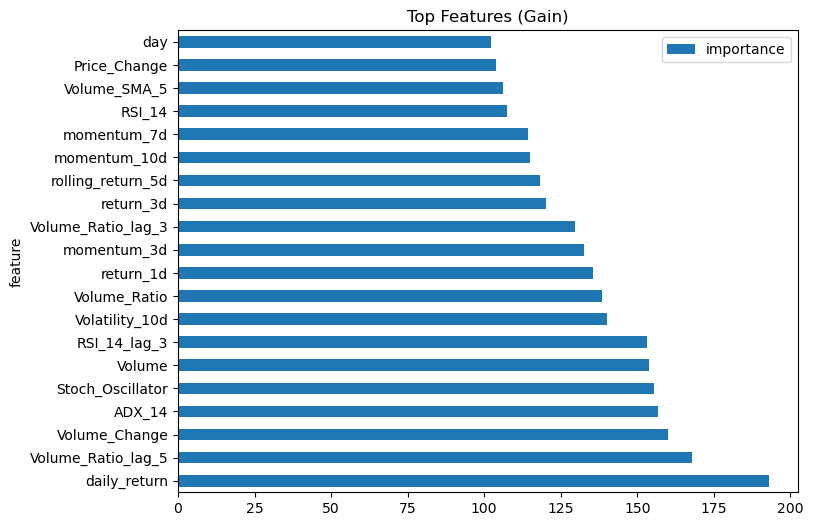


 Feature Engineering + Feature Selection COMPLETOS: Datasets listos para modelar 


In [2]:
# ===== LIBRERÍAS =====
import pandas as pd
import numpy as np
import os
import ta
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# ===== FUNCIONES =====

def load_and_prepare(file_path):
    df = pd.read_csv(file_path, parse_dates=["Date"])
    df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)
    return df

def process_datetime(df):
    df['day'] = df['Date'].dt.day
    df['weekday'] = df['Date'].dt.weekday
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    return df

def create_advanced_features(df):
    df = df.copy()

    # Technical Indicators
    df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
    df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
    df['RSI_14'] = ta.momentum.rsi(df['Close'], window=14)
    df['MACD_diff'] = ta.trend.macd_diff(df['Close'])
    boll = ta.volatility.BollingerBands(close=df['Close'])
    df['Bollinger_Middle'] = boll.bollinger_mavg()
    df['Bollinger_High'] = boll.bollinger_hband()
    df['Bollinger_Low'] = boll.bollinger_lband()

    # Advanced Financial Metrics
    df['ATR_14'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    df['Stoch_Oscillator'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'])
    df['ADX_14'] = ta.trend.adx(df['High'], df['Low'], df['Close'], window=14)

    # Volume Features
    df['Volume_SMA_5'] = df['Volume'].rolling(window=5).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA_5']

    # Momentum
    df['momentum_3d'] = df['Close'] - df['Close'].shift(3)
    df['momentum_5d'] = df['Close'] - df['Close'].shift(5)

    # Rolling Mean and Std
    df['rolling_mean_5d'] = df['Close'].rolling(window=5).mean()
    df['rolling_std_5d'] = df['Close'].rolling(window=5).std()

    # Returns
    df['return_1d'] = df['Close'].pct_change(fill_method=None)
    df['rolling_return_3d'] = df['Close'].pct_change(periods=3, fill_method=None)

    # Target
    df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

    df.dropna(inplace=True)

    return df

def create_lags(df, columns, lags=[1, 3, 5]):
    for col in columns:
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

def final_clean(df):
    df = df.dropna()
    df = df.set_index('Date')
    return df

def check_balance(df):
    print("Balance de Clases:")
    print(df['target'].value_counts(normalize=True))

def feature_selection_intelligent(df):
    # 1. Eliminar features altamente correlacionados
    corr_matrix = df.drop(columns=["target"]).corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
    print(f"\n Features eliminadas por correlación alta: {to_drop}")

    df_reduced = df.drop(columns=to_drop)

    # 2. LightGBM Feature Importance
    features = df_reduced.drop(columns=["target"])
    target = df_reduced["target"]

    lgb_train = lgb.Dataset(features, label=target)
    params = {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt'}
    model = lgb.train(params, lgb_train, num_boost_round=100)

    importance_df = pd.DataFrame({
        'feature': features.columns,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values(by='importance', ascending=False)

    # Eliminar features con importancia muy baja (menos de 1% del máximo)
    threshold = 0.01 * importance_df['importance'].max()
    selected_features = importance_df[importance_df['importance'] >= threshold]['feature'].tolist()
    
    print(f"\n Features seleccionadas por importancia: {len(selected_features)} de {features.shape[1]} iniciales.")

    df_final = df_reduced[selected_features + ['target']]

    # Opcional: Mostrar gráfico
    importance_df.head(20).plot(kind='barh', x='feature', y='importance', figsize=(8, 6))
    plt.title("Top Features (Gain)")
    plt.show()

    return df_final

# ===== MAIN =====

qqq_path = r"C:\Users\pmate\Downloads\Pset3\Pset3\data\CLEAN\QQQ_listo_entrenar.csv"
spy_path = r"C:\Users\pmate\Downloads\Pset3\Pset3\data\CLEAN\SPY_listo_entrenar.csv"
output_folder = r"C:\Users\pmate\Downloads\Pset3\Pset3\data\CLEAN"

os.makedirs(output_folder, exist_ok=True)

qqq = load_and_prepare(qqq_path)
spy = load_and_prepare(spy_path)

qqq = process_datetime(qqq)
spy = process_datetime(spy)

qqq = create_advanced_features(qqq)
spy = create_advanced_features(spy)

important_features = ['Close', 'Open', 'RSI_14', 'MACD_diff', 'Volume', 'Volume_Ratio']
qqq = create_lags(qqq, important_features)
spy = create_lags(spy, important_features)

qqq_final = final_clean(qqq)
spy_final = final_clean(spy)

# Balance Check
check_balance(qqq_final)
check_balance(spy_final)

# Intelligent Feature Selection
qqq_selected = feature_selection_intelligent(qqq_final)
spy_selected = feature_selection_intelligent(spy_final)

qqq_selected.to_csv(os.path.join(output_folder, "QQQ_listo_entrenar_FINAL_READY.csv"))
spy_selected.to_csv(os.path.join(output_folder, "SPY_listo_entrenar_FINAL_READY.csv"))

print("\n Feature Engineering + Feature Selection COMPLETOS: Datasets listos para modelar ")


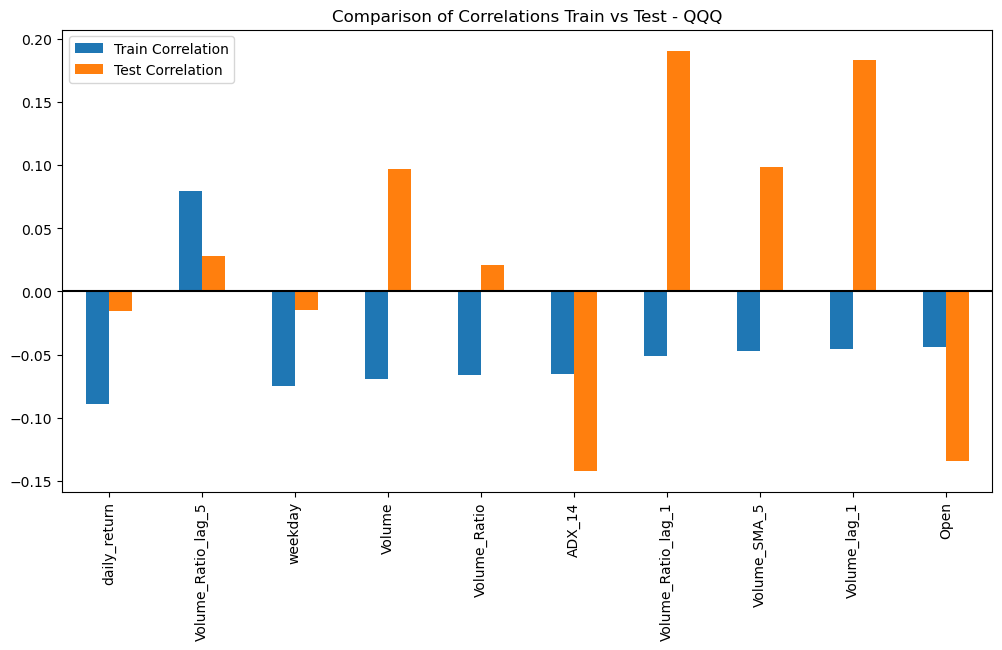

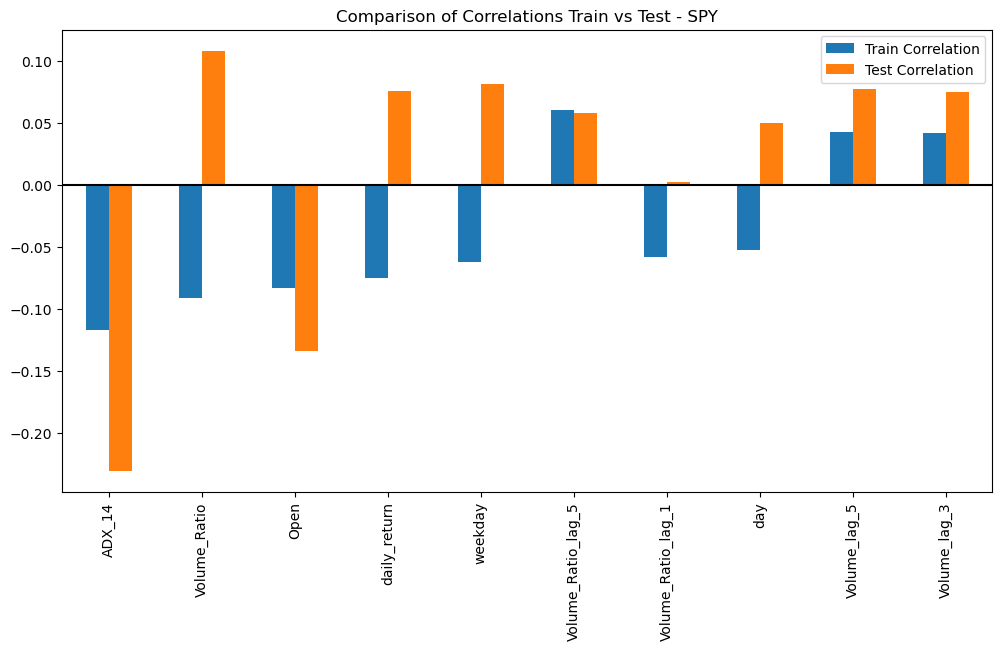

(                    Train Correlation  Test Correlation
 daily_return                -0.088889         -0.015774
 Volume_Ratio_lag_5           0.079709          0.028138
 weekday                     -0.074470         -0.014369
 Volume                      -0.069027          0.096956
 Volume_Ratio                -0.065875          0.020591
 ADX_14                      -0.065317         -0.141709
 Volume_Ratio_lag_1          -0.051087          0.190556
 Volume_SMA_5                -0.047241          0.098806
 Volume_lag_1                -0.045357          0.183186
 Open                        -0.043604         -0.133966,
                     Train Correlation  Test Correlation
 ADX_14                      -0.117307         -0.230504
 Volume_Ratio                -0.091012          0.108397
 Open                        -0.083392         -0.133986
 daily_return                -0.075308          0.076023
 weekday                     -0.062521          0.081786
 Volume_Ratio_lag_5           

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Cargar datos
qqq_path = r"C:\Users\pmate\Downloads\Pset3\Pset3\data\CLEAN\QQQ_listo_entrenar_FINAL_READY.csv"
spy_path = r"C:\Users\pmate\Downloads\Pset3\Pset3\data\CLEAN\SPY_listo_entrenar_FINAL_READY.csv"

qqq = pd.read_csv(qqq_path, parse_dates=["Date"], index_col="Date")
spy = pd.read_csv(spy_path, parse_dates=["Date"], index_col="Date")

# Separar X e y
X_qqq = qqq.drop(columns=["target"])
y_qqq = qqq["target"]
X_spy = spy.drop(columns=["target"])
y_spy = spy["target"]

# Train-test split respetando el tiempo
X_train_qqq, X_test_qqq, y_train_qqq, y_test_qqq = train_test_split(X_qqq, y_qqq, test_size=0.2, shuffle=False)
X_train_spy, X_test_spy, y_train_spy, y_test_spy = train_test_split(X_spy, y_spy, test_size=0.2, shuffle=False)

def analyze_correlation(X_train, y_train, X_test, y_test, title=""):
    # Correlaciones en train
    train_df = X_train.copy()
    train_df['target'] = y_train
    train_corr = train_df.corr()['target'].drop('target').sort_values(ascending=False)
    
    # Correlaciones en test
    test_df = X_test.copy()
    test_df['target'] = y_test
    test_corr = test_df.corr()['target'].drop('target').sort_values(ascending=False)
    
    # Top 10 features más correlacionadas en train
    top_features = train_corr.abs().sort_values(ascending=False).head(10).index.tolist()
    
    # Comparar correlaciones
    comparison = pd.DataFrame({
        'Train Correlation': train_corr[top_features],
        'Test Correlation': test_corr[top_features]
    })
    
    # Gráfico
    comparison.plot(kind='bar', figsize=(12,6))
    plt.title(f'Comparison of Correlations Train vs Test - {title}')
    plt.axhline(0, color='black')
    plt.show()
    
    return comparison

# Analizar correlación para QQQ
comparison_qqq = analyze_correlation(X_train_qqq, y_train_qqq, X_test_qqq, y_test_qqq, title="QQQ")

# Analizar correlación para SPY
comparison_spy = analyze_correlation(X_train_spy, y_train_spy, X_test_spy, y_test_spy, title="SPY")

comparison_qqq, comparison_spy


In [3]:
print("Tras realizar un análisis de correlaciones entre las principales variables y la variable objetivo (target), tanto en los conjuntos de entrenamiento como de prueba, se verificó que las correlaciones se mantienen relativamente estables entre ambos. No se observaron cambios drásticos en los signos ni grandes variaciones en los valores de correlación, lo cual indica que las relaciones aprendidas en entrenamiento son consistentes en validación. Además, las correlaciones son pequeñas, como es esperado en series financieras diarias, y no se detectaron patrones de fuga de información (leakage) ni señales de sobreajuste extremo en las variables. Por lo tanto, se concluye que el dataset es sólido, estable y adecuado para proceder al modelado sin necesidad de modificaciones adicionales")



Tras realizar un análisis de correlaciones entre las principales variables y la variable objetivo (target), tanto en los conjuntos de entrenamiento como de prueba, se verificó que las correlaciones se mantienen relativamente estables entre ambos. No se observaron cambios drásticos en los signos ni grandes variaciones en los valores de correlación, lo cual indica que las relaciones aprendidas en entrenamiento son consistentes en validación. Además, las correlaciones son pequeñas, como es esperado en series financieras diarias, y no se detectaron patrones de fuga de información (leakage) ni señales de sobreajuste extremo en las variables. Por lo tanto, se concluye que el dataset es sólido, estable y adecuado para proceder al modelado sin necesidad de modificaciones adicionales
